In [ ]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# Automatically generating object masks with SAM

Since SAM can efficiently process prompts, masks for the entire image can be generated by sampling a large number of prompts over an image. This method was used to generate the dataset SA-1B.

The class `SamAutomaticMaskGenerator` implements this capability. It works by sampling single-point input prompts in a grid over the image, from each of which SAM can predict multiple masks. Then, masks are filtered for quality and deduplicated using non-maximal suppression. Additional options allow for further improvement of mask quality and quantity, such as running prediction on multiple crops of the image or postprocessing masks to remove small disconnected regions and holes.

## Environment Set-up

If running locally using jupyter, first install `segment_anything` in your environment using the [installation instructions](https://github.com/facebookresearch/segment-anything#installation) in the repository. If running from Google Colab, set `using_colab=True` below and run the cell. In Colab, be sure to select 'GPU' under 'Edit'->'Notebook Settings'->'Hardware accelerator'.

In [1]:
using_colab = True

In [2]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

    !mkdir images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg

    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

PyTorch version: 2.6.0+cu124
Torchvision version: 0.21.0+cu124
CUDA is available: True
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-ff1k_ss9
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-ff1k_ss9
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=e24188aeb3002c793339a1cb0b258553bd88a67a47654e83da75b7f740f91a78
  Stored in directory: /tmp/pip-ephem-wheel-cache-rs_3s1zc/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything
--2025-04-15 08:36:49--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com

## Set-up

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

In [8]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

## Example image

In [74]:
dic_path = '/content/SBW25WTGFP_CAAIPTG_1_100cell_droplet-04_t091_DIC II 40x_ORG.tif'
fluo_path = '/content/SBW25WTGFP_CAAIPTG_1_100cell_droplet-04_t090_EGFP_ORG.tif'

### plot compressé

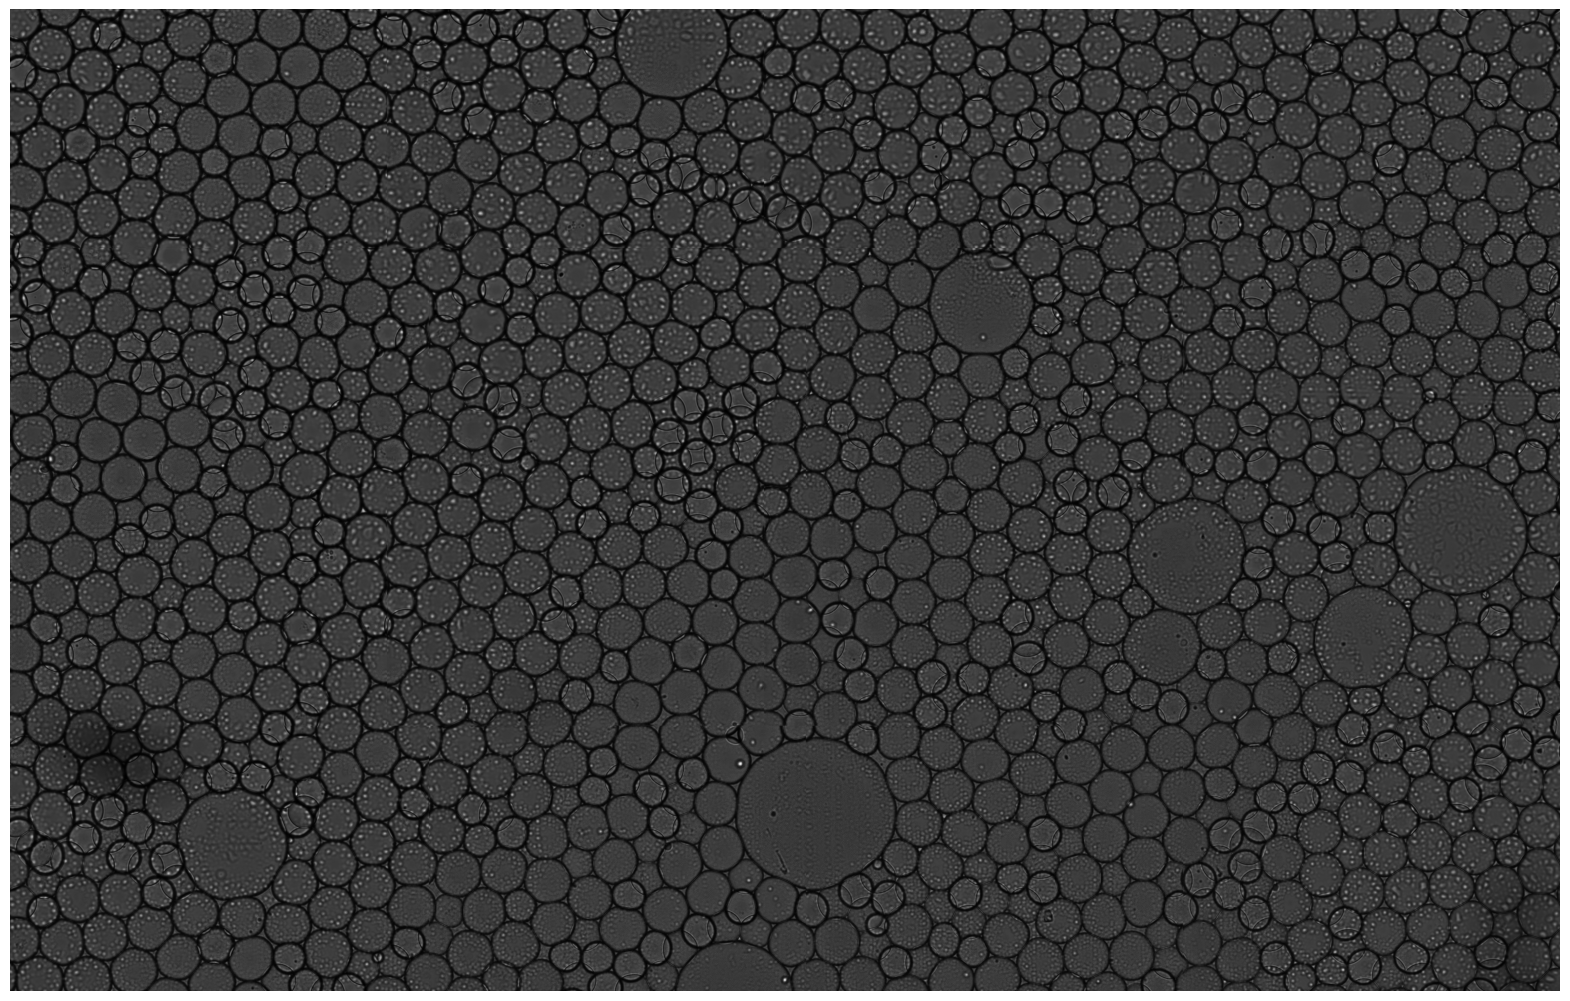

In [24]:
image = cv2.imread(path_DIC)

image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

### ROI things

In [76]:
image = cv2.imread(dic_path)
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#### code extract roi et show

In [77]:
# prompt: fais une fonction qui fait une roi d'une image avec en entrée la path de l'image et la taille de la roi

import cv2
import matplotlib.pyplot as plt

def extract_roi(image_path, x_min, y_min, x_max, y_max):
    """
    Extracts a region of interest (ROI) from an image.

    Args:
        image_path: The path to the image file.
        x_min: The minimum x-coordinate of the ROI.
        y_min: The minimum y-coordinate of the ROI.
        x_max: The maximum x-coordinate of the ROI.
        y_max: The maximum y-coordinate of the ROI.

    Returns:
        The ROI as a NumPy array, or None if the image cannot be read or the ROI coordinates are invalid.
    """
    image = cv2.imread(image_path)

    if image is None:
        print(f"Erreur : Impossible de lire l'image à partir du chemin : {image_path}")
        return None
    image_height, image_width = image.shape[:2]

    # Validate ROI coordinates
    if not (0 <= x_min < x_max <= image_width and 0 <= y_min < y_max <= image_height):
        print("Erreur : Les coordonnées de la ROI sont invalides.")
        return None

    roi = image[y_min:y_max, x_min:x_max]
    return roi

def show_roi(image_path, roi):
    """
    Displays the original image and the extracted ROI side-by-side.
    """
    image = cv2.imread(image_path)
    if image is None or roi is None:
        return

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Image originale")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    plt.title("ROI")
    plt.axis('off')

    plt.show()





#### exécution

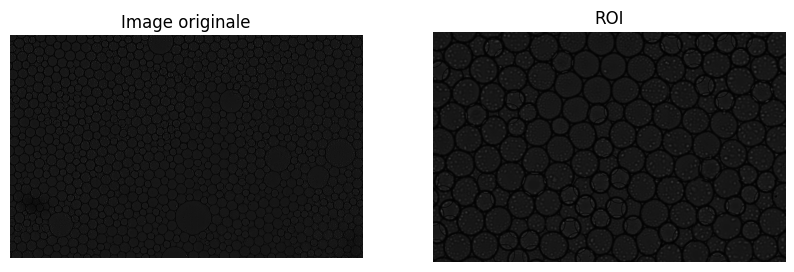

In [78]:
# Example usage
x_min, y_min, x_max, y_max = 0, 0, 2600, 1700

dic_roi = extract_roi(dic_path, x_min, y_min, x_max, y_max)

if dic_roi is not None:
    show_roi(dic_path, dic_roi)

## Automatic mask generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

In [14]:
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)

To generate masks, just run `generate` on an image.

In [79]:
masks = mask_generator.generate(dic_roi)

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:
* `segmentation` : the mask
* `area` : the area of the mask in pixels
* `bbox` : the boundary box of the mask in XYWH format
* `predicted_iou` : the model's own prediction for the quality of the mask
* `point_coords` : the sampled input point that generated this mask
* `stability_score` : an additional measure of mask quality
* `crop_box` : the crop of the image used to generate this mask in XYWH format

In [80]:
print(len(masks))
print(masks[0].keys())

193
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


Show all the masks overlayed on the image.

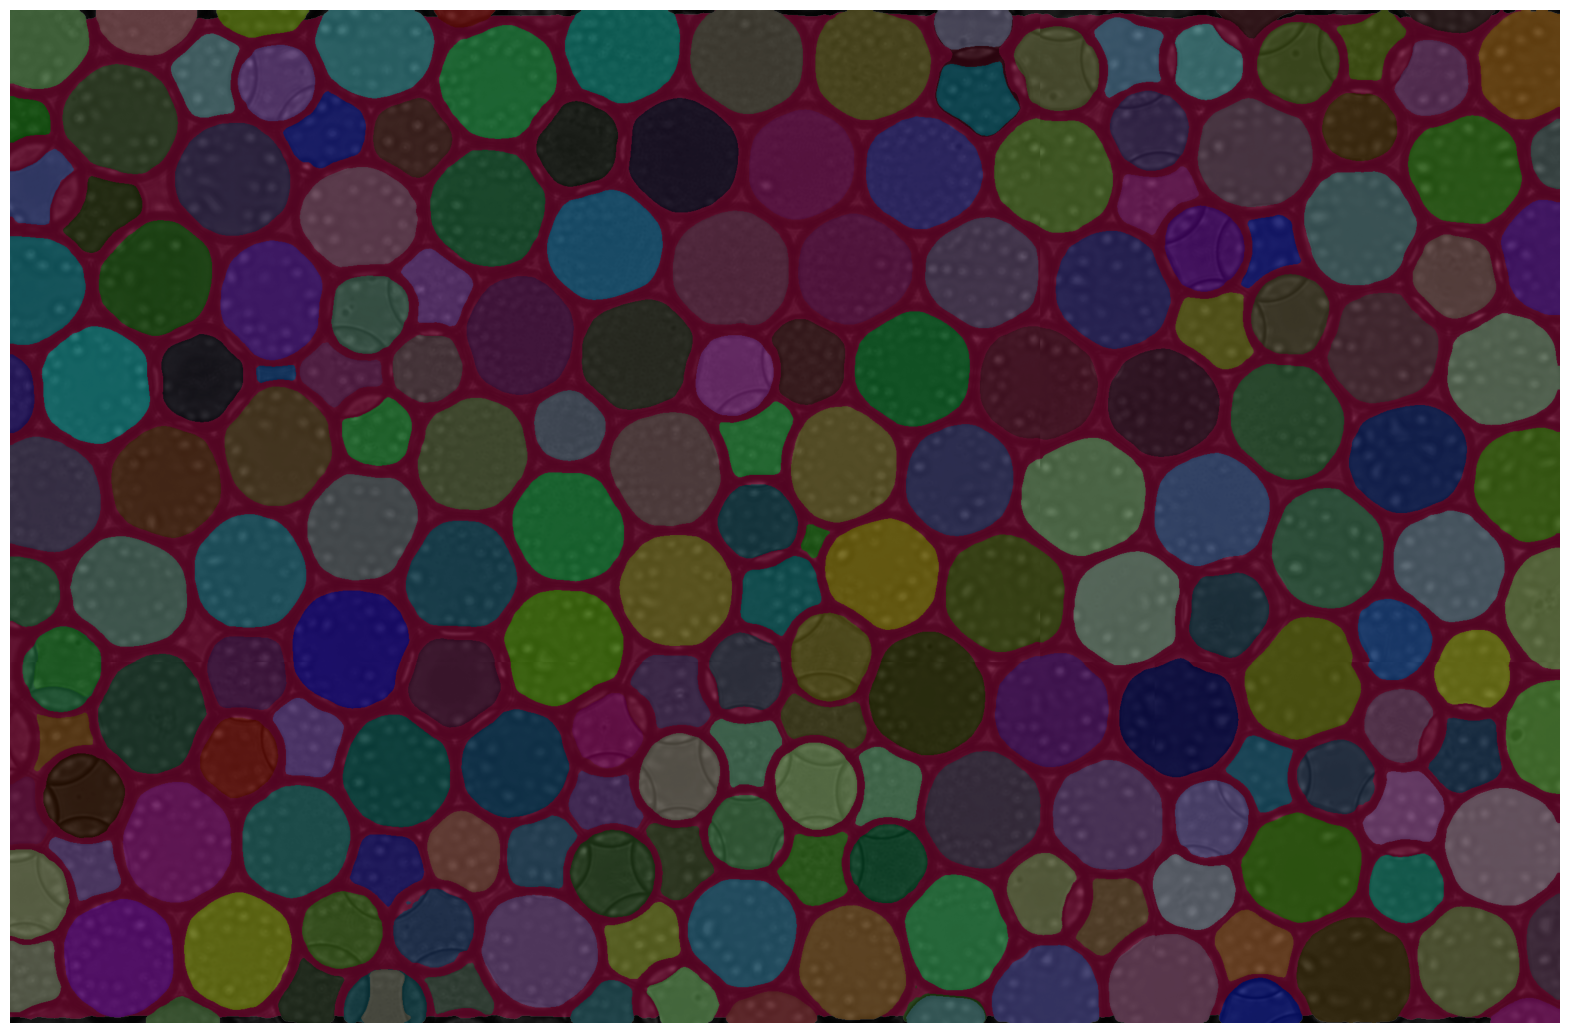

In [81]:
plt.figure(figsize=(20,20))
plt.imshow(dic_roi)
show_anns(masks)
plt.axis('off')
plt.show()

In [84]:
# prompt: affiche les masks un à la fois, contrôlé par un clic sur un bouton 'next mask'

import matplotlib.pyplot as plt
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

# Assuming 'masks' is your list of masks from mask_generator.generate(roi)

mask_index = 0
max_index = len(masks) - 1

# Create a button
button = widgets.Button(description="Next Mask")

# Create an output widget to display the mask
output = widgets.Output()

# Function to display the mask and update the index
def on_button_clicked(b):
    global mask_index
    with output:
        clear_output(wait=True)  # Clear the previous mask
        if 0 <= mask_index <= max_index:
          plt.imshow(masks[mask_index]['segmentation'] * dic_roi[:,:,1])
          plt.imshow(dic_roi, alpha = 0.4)
          plt.title(f"Mask {mask_index + 1}/{max_index + 1}")
          plt.axis('off')
          plt.show()
          mask_index += 1
        else:
            print("No more masks to display.")


button.on_click(on_button_clicked)


display(button)
display(output)

# Display the first mask initially
on_button_clicked(None)


Button(description='Next Mask', style=ButtonStyle())

Output()

In [91]:
# shape de fluo = shape de dic

import cv2

fluo = cv2.imread(fluo_path)
dic = cv2.imread(dic_path)

if fluo is None or dic is None:
    print("Error: Could not load one or both images.")
else:
    if fluo.shape == dic.shape:
        print("The shapes of fluo and dic are the same.")
    else:
        print("The shapes of fluo and dic are different.")
        print(f"fluo shape: {fluo.shape}, dic shape: {dic.shape}")


The shapes of fluo and dic are the same.


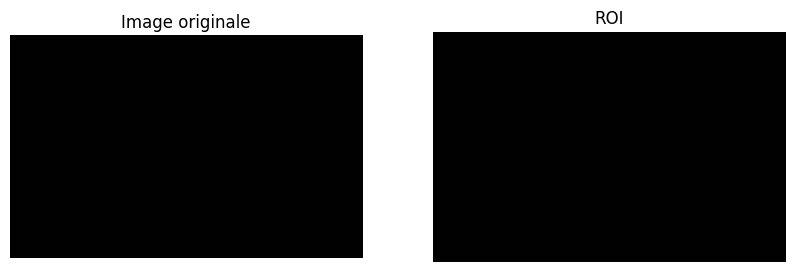

In [92]:
fluo_roi = extract_roi(fluo_path, 0, 0, 2600, 1700)
#fluo_roi = cv2.normalize(fluo_roi, None, 0, 255, cv2.NORM_MINMAX)
show_roi(fluo_path, fluo_roi)

In [93]:
# prompt: calculer la fluorescence moyenne dans une cellule sur fluo.tif, délimitée par le masque fait à partir de droplet.png

import numpy as np

# Assuming 'masks' is your list of masks from mask_generator.generate(roi)
# and 'fluo' is your fluorescence image loaded as a NumPy array

def calculate_average_fluorescence(fluo_image, mask):
    """Calculates the average fluorescence intensity within a given mask.

    Args:
        fluo_image: NumPy array representing the fluorescence image.
        mask: NumPy array representing the binary mask (0 or 1).

    Returns:
        The average fluorescence intensity within the mask, or NaN if the mask is empty.
    """
    masked_fluorescence = fluo_image[mask > 0]
    if len(masked_fluorescence) == 0:
        return np.nan  # Return NaN if the mask doesn't cover any pixels
    return np.mean(masked_fluorescence)

mask_index = 0
for mask in masks:
    current_mask = mask['segmentation']
    average_fluo = calculate_average_fluorescence(fluo_roi, current_mask)

    if np.isnan(average_fluo):
        print(f"Mask {mask_index} is empty. Cannot calculate average fluorescence.")
    else:
        print(f"Average fluorescence in mask {mask_index}: {average_fluo}")
    mask_index += 1


Average fluorescence in mask 0: 1.0
Average fluorescence in mask 1: 1.0
Average fluorescence in mask 2: 1.0
Average fluorescence in mask 3: 1.0
Average fluorescence in mask 4: 1.0
Average fluorescence in mask 5: 1.0
Average fluorescence in mask 6: 1.0
Average fluorescence in mask 7: 1.0
Average fluorescence in mask 8: 1.0
Average fluorescence in mask 9: 1.0
Average fluorescence in mask 10: 1.0
Average fluorescence in mask 11: 1.0
Average fluorescence in mask 12: 1.0
Average fluorescence in mask 13: 1.0
Average fluorescence in mask 14: 1.0
Average fluorescence in mask 15: 1.0
Average fluorescence in mask 16: 1.0
Average fluorescence in mask 17: 1.0
Average fluorescence in mask 18: 1.0
Average fluorescence in mask 19: 1.0
Average fluorescence in mask 20: 1.0
Average fluorescence in mask 21: 1.0
Average fluorescence in mask 22: 1.0
Average fluorescence in mask 23: 1.0
Average fluorescence in mask 24: 1.0
Average fluorescence in mask 25: 1.0
Average fluorescence in mask 26: 1.0
Average flu

## Automatic mask generation options

There are several tunable parameters in automatic mask generation that control how densely points are sampled and what the thresholds are for removing low quality or duplicate masks. Additionally, generation can be automatically run on crops of the image to get improved performance on smaller objects, and post-processing can remove stray pixels and holes. Here is an example configuration that samples more masks:

In [72]:
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=500,  # Requires open-cv to run post-processing
)

In [ ]:
masks2 = mask_generator_2.generate(roi)

KeyboardInterrupt: 

In [ ]:
len(masks2)

In [ ]:
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.show()